# Descripción del proyecto

La compañía Sweet Lift Taxi ha recopilado datos históricos sobre pedidos de taxis en los aeropuertos. Para atraer a más conductores durante las horas pico, necesitamos predecir la cantidad de pedidos de taxis para la próxima hora. Construye un modelo para dicha predicción.

La métrica RECM en el conjunto de prueba no debe ser superior a 48.

## Instrucciones del proyecto.

1. Descarga los datos y haz el remuestreo por una hora.
2. Analiza los datos
3. Entrena diferentes modelos con diferentes hiperparámetros. La muestra de prueba debe ser el 10% del conjunto de datos inicial.4. Prueba los datos usando la muestra de prueba y proporciona una conclusión.

## Descripción de los datos

Los datos se almacenan en el archivo `taxi.csv`. 	
El número de pedidos está en la columna `num_orders`.

## Preparación

In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
from statsmodels.tsa.seasonal import seasonal_decompose

# Cargar datos
df = pd.read_csv('/datasets/taxi.csv', index_col=[0], parse_dates=[0])
df.sort_index(inplace=True)

In [2]:
# Remuestrear a intervalos de 1 hora
df = df.resample('1H').sum()

print(df.shape)
print(df.head())
print(df.info())

(4416, 1)
                     num_orders
datetime                       
2018-03-01 00:00:00         124
2018-03-01 01:00:00          85
2018-03-01 02:00:00          71
2018-03-01 03:00:00          66
2018-03-01 04:00:00          43
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB
None


## Análisis

In [3]:
# Estadísticas descriptivas
print(df.describe())

        num_orders
count  4416.000000
mean     84.422781
std      45.023853
min       0.000000
25%      54.000000
50%      78.000000
75%     107.000000
max     462.000000


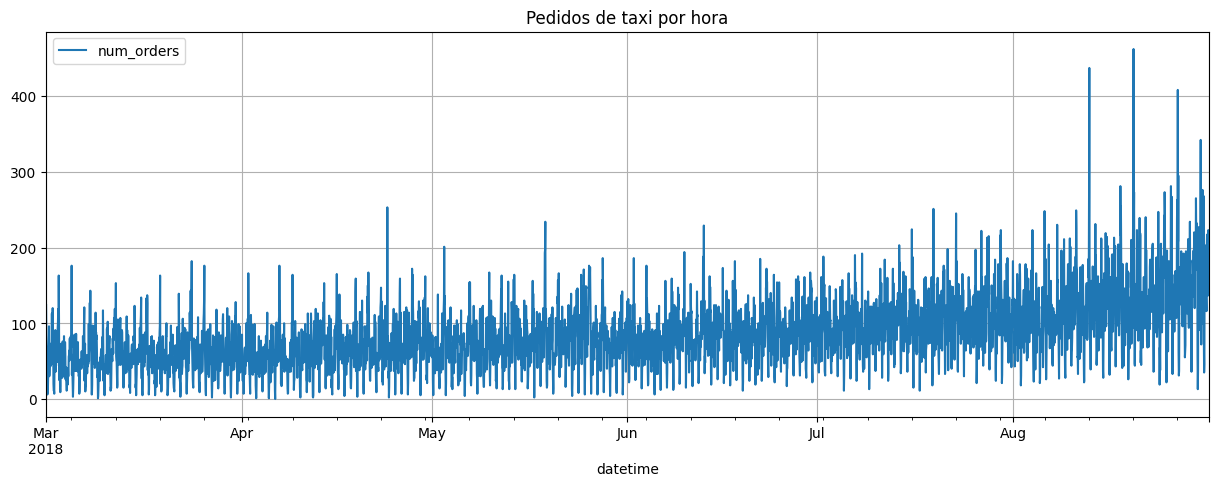

In [4]:
# Gráfico de la serie completa
df.plot(figsize=(15, 5), title='Pedidos de taxi por hora')
plt.grid(True)
plt.show()

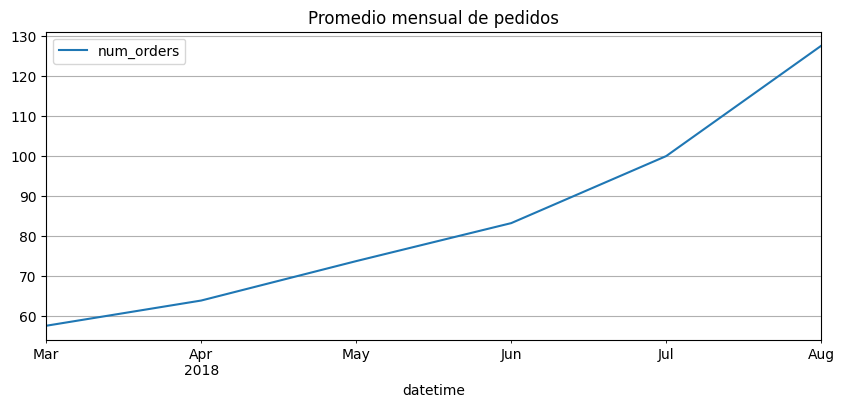

In [5]:
# Consumo promedio por mes
df.resample('M').mean().plot(figsize=(10, 4), title='Promedio mensual de pedidos')
plt.grid(True)
plt.show()

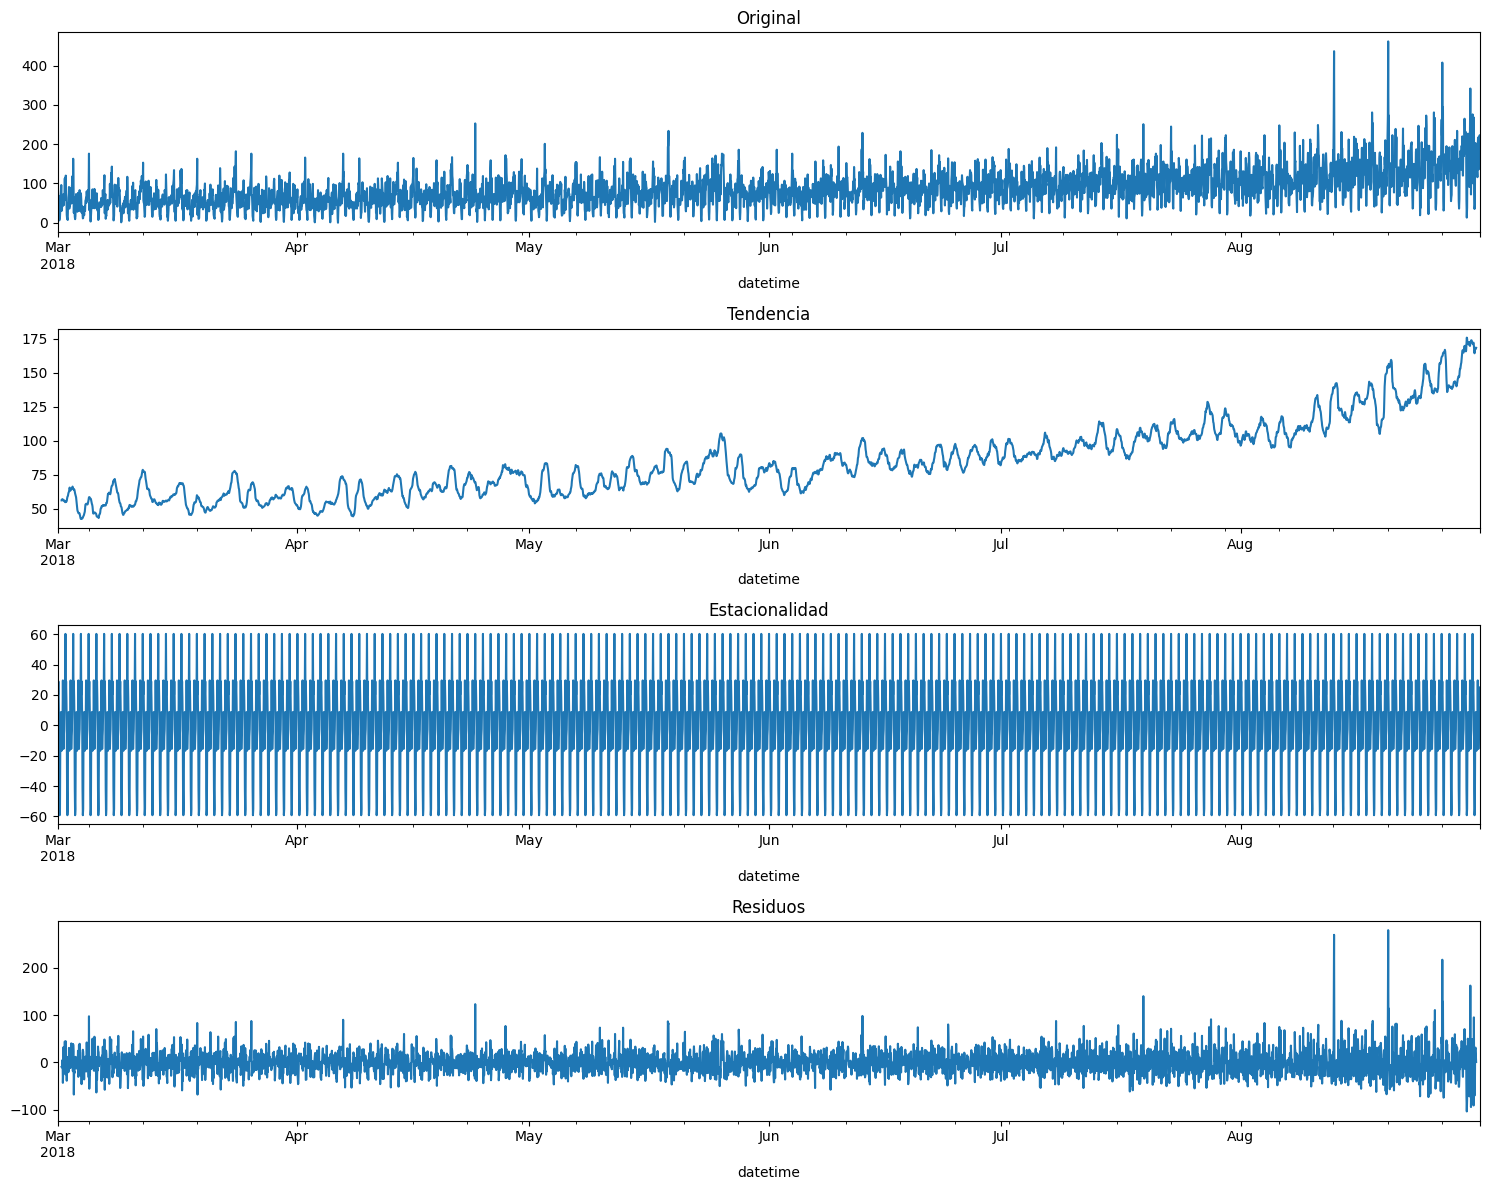

In [6]:
# Descomposición estacional
decomposed = seasonal_decompose(df, period=24)
fig, axes = plt.subplots(4, 1, figsize=(15, 12))
decomposed.observed.plot(ax=axes[0], title='Original')
decomposed.trend.plot(ax=axes[1], title='Tendencia')
decomposed.seasonal.plot(ax=axes[2], title='Estacionalidad')
decomposed.resid.plot(ax=axes[3], title='Residuos')
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">

<b>Comentario del revisor</b> <a class="tocSkip"></a>


Excelente! 

Complementas con una  gráficas nos ayudan a identificar posibles estacionalidades. 


Puedes complementar con el gráfico de las medias moviles para capturar efectos de corto plazo y ayuda a suavizar las fluctuaciones 

## Formación

In [7]:
# Función para crear características
def make_features(data, max_lag, rolling_mean_size):
    data['hour']      = data.index.hour
    data['dayofweek'] = data.index.dayofweek
    data['month']     = data.index.month
    
    for lag in range(1, max_lag + 1):
        data[f'lag_{lag}'] = data['num_orders'].shift(lag)
    
    data['rolling_mean'] = data['num_orders'].shift(1).rolling(rolling_mean_size).mean()

make_features(df, max_lag=24, rolling_mean_size=24)

In [8]:
# División train/test 90:10
train, test = train_test_split(df, shuffle=False, test_size=0.1)
train = train.dropna()

features = [col for col in df.columns if col != 'num_orders']
X_train = train[features]
y_train = train['num_orders']
X_test  = test[features]
y_test  = test['num_orders']

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

Train: (3950, 28)
Test: (442, 28)


## Prueba

### Modelo 1 — Regresión Lineal (prueba de cordura)

In [9]:

lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
rmse_lr = mean_squared_error(y_test, pred_lr) ** 0.5

print(f"Regresión Lineal RMSE: {rmse_lr:.2f}")

Regresión Lineal RMSE: 45.68


### Modelo 2 — Random Forest

In [10]:

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=12345, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
rmse_rf = mean_squared_error(y_test, pred_rf) ** 0.5

print(f"Random Forest RMSE: {rmse_rf:.2f}")

Random Forest RMSE: 44.99


### Modelo 3 — LightGBM

In [11]:
lgbm = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05,
                          num_leaves=31, random_state=12345, n_jobs=-1)
lgbm.fit(X_train, y_train)
pred_lgbm = lgbm.predict(X_test)
rmse_lgbm = mean_squared_error(y_test, pred_lgbm) ** 0.5

print(f"LightGBM RMSE: {rmse_lgbm:.2f}")

LightGBM RMSE: 41.34


## Conclusiones

In [12]:
# Tabla comparativa
results = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Random Forest', 'LightGBM'],
    'RECM': [rmse_lr, rmse_rf, rmse_lgbm]
}).sort_values('RECM').reset_index(drop=True)

print(results.to_string(index=False))

          Modelo      RECM
        LightGBM 41.336075
   Random Forest 44.994263
Regresión Lineal 45.679094


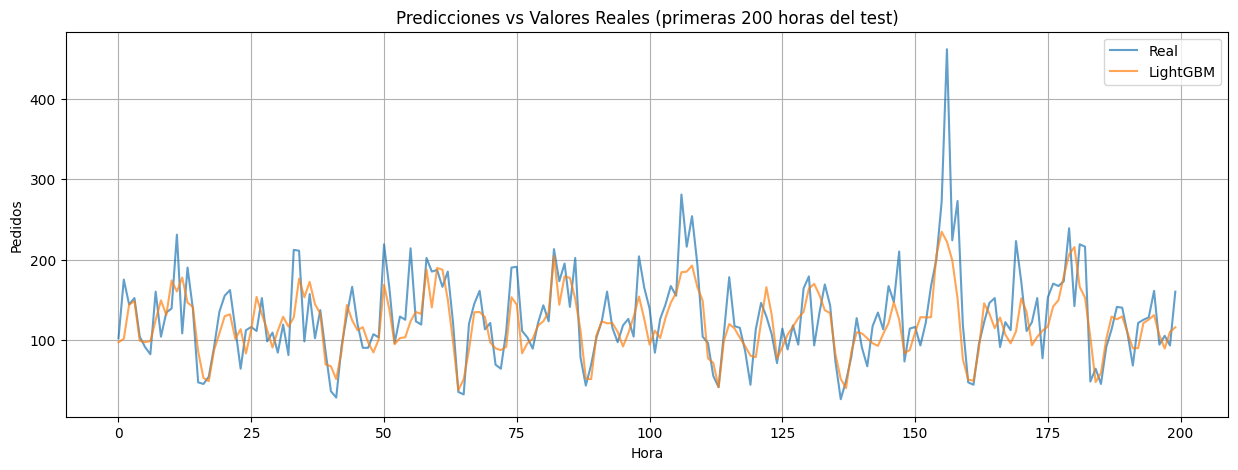

In [13]:
# Gráfico de predicciones vs valores reales
plt.figure(figsize=(15, 5))
plt.plot(y_test.values[:200], label='Real', alpha=0.7)
plt.plot(pred_lgbm[:200], label='LightGBM', alpha=0.7)
plt.title('Predicciones vs Valores Reales (primeras 200 horas del test)')
plt.xlabel('Hora')
plt.ylabel('Pedidos')
plt.legend()
plt.grid(True)
plt.show()

Los 3 modelos cumplen el requisito de $RMSE < 48$.

__LightGBM__ es el mejor modelo con $RMSE = 41.34$, superando en ~7 puntos el umbral requerido.

Las características más importantes fueron los lags de 24 horas (_capturan el patrón diario_) y la media móvil (_suaviza las fluctuaciones_).

La regresión lineal ya supera el umbral, lo que confirma que las características de calendario y lags son muy informativas para este problema.


*__Recomendación:__* usar LightGBM en producción por su mejor RMSE y velocidad de entrenamiento superior a Random Forest.

# Lista de revisión

- [x]  	
Jupyter Notebook está abierto.
- [x]  El código no tiene errores
- [x]  Las celdas con el código han sido colocadas en el orden de ejecución.
- [x]  Los datos han sido descargados y preparados.
- [x]  Se ha realizado el paso 2: los datos han sido analizados
- [x]  Se entrenó el modelo y se seleccionaron los hiperparámetros
- [x]  Se han evaluado los modelos. Se expuso una conclusión
- [x] La *RECM* para el conjunto de prueba no es más de 48